# MDC Anomaly Detection — Model v2

**Loads:** `windows_v2.npz` from `mdc_preprocess_v2.ipynb` (leakage-free pipeline)

**Key improvements over v1:**
1. **Sinusoidal positional encoding** — Transformer now knows time order
2. **Temporal bottleneck** — mean-pool over T steps → compress to `bottleneck_dim` → expand back; forces learning compact normal patterns
3. **Denoising autoencoder** — optional Gaussian noise injection during training
4. **Better anomaly scoring** — weighted mean + max reconstruction error per window
5. **Multiple thresholding** — Youden J, p95/p99 benign, F1-optimal, precision-target
6. **Complete evaluation** — ROC-AUC, PR-AUC, F1, MCC, balanced accuracy, specificity, FPR, FNR
7. **Optuna HPO** — automated hyperparameter search with pruning
8. **Score distribution plots** — benign vs attack separation visualized

## 0. Environment

In [1]:
import sys, subprocess

try:
    import google.colab
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

if _IN_COLAB:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'torch', 'scikit-learn', 'matplotlib', 'optuna'],
        check=False,
    )

print(f'Running in Colab: {_IN_COLAB}')

Running in Colab: True


## 1. Configuration & Reproducibility

In [2]:
from __future__ import annotations
import json, os, random, gc
from pathlib import Path
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Training
BATCH_SIZE    = 32
MAX_EPOCHS    = 100
PATIENCE      = 20
LR            = 5e-4
WEIGHT_DECAY  = 1e-4
DROPOUT       = 0.20
GRAD_CLIP     = 1.0

# Architecture  (DIM_FF halved, N_DEC_LAYERS reduced — biggest RAM savings)
D_MODEL        = 64
N_HEAD         = 4
N_ENC_LAYERS   = 2
N_DEC_LAYERS   = 1
DIM_FF         = 128
BOTTLENECK_DIM = 32

# Denoising
USE_DENOISING  = True
NOISE_STD      = 0.05

# Scoring  (small batch size keeps peak RAM low)
SCORE_MEAN_W    = 0.7
SCORE_MAX_W     = 0.3
SCORE_BATCH_SIZE = 128

# HPO  (halved for speed and RAM)
N_TRIALS      = 15
HPO_MAX_EPOCH = 30
HPO_PATIENCE  = 8

# Paths
if _IN_COLAB:
    RUN_DIR  = Path("/content/drive/MyDrive/Module4_MDC/runs/v2_run")
    DATA_DIR = Path("/content/drive/MyDrive/Module4_MDC/processed_v2")
else:
    RUN_DIR  = Path("../outputs/mdc_v2_run")
    DATA_DIR = Path("../data/processed")

print("Config loaded.")
print(f"  DATA_DIR : {DATA_DIR}")
print(f"  Model    : D_MODEL={D_MODEL}  BOTTLENECK={BOTTLENECK_DIM}  N_ENC={N_ENC_LAYERS}  N_DEC={N_DEC_LAYERS}  DIM_FF={DIM_FF}")
print(f"  Training : LR={LR}  BATCH={BATCH_SIZE}  MAX_EPOCHS={MAX_EPOCHS}  PATIENCE={PATIENCE}")
print(f"  HPO      : N_TRIALS={N_TRIALS}  HPO_MAX_EPOCH={HPO_MAX_EPOCH}")


Config loaded.
  DATA_DIR : /content/drive/MyDrive/Module4_MDC/processed_v2
  Model    : D_MODEL=64  BOTTLENECK=32  N_ENC=2  N_DEC=1  DIM_FF=128
  Training : LR=0.0005  BATCH=32  MAX_EPOCHS=100  PATIENCE=20
  HPO      : N_TRIALS=15  HPO_MAX_EPOCH=30


## 2. Mount Drive & Load `windows_v2.npz`

In [5]:
import os, shutil, gc
from pathlib import Path
import numpy as np

if _IN_COLAB:
    from google.colab import drive
    _mount = "/content/drive"
    try:
        drive.flush_and_unmount()
    except Exception:
        pass
    if os.path.exists(_mount):
        shutil.rmtree(_mount)
    os.makedirs(_mount, exist_ok=True)
    drive.mount(_mount)

NPZ_PATH = DATA_DIR / "windows_v2.npz"

if not NPZ_PATH.is_file() and _IN_COLAB:
    myd = Path("/content/drive/MyDrive")
    hits = sorted(myd.rglob("windows_v2.npz"), key=lambda p: len(str(p)))
    if hits:
        NPZ_PATH = hits[0]
        print(f"Found at: {NPZ_PATH}")
    else:
        hits_v1 = sorted(myd.rglob("windows.npz"), key=lambda p: len(str(p)))
        if hits_v1:
            NPZ_PATH = hits_v1[0]
            print(f"[WARN] windows_v2.npz not found, falling back to: {NPZ_PATH}")

if not NPZ_PATH.is_file():
    raise FileNotFoundError(
        "windows_v2.npz not found at " + str(NPZ_PATH) +
        ". Run mdc_preprocess_v2.ipynb first to generate it."
    )

z = np.load(NPZ_PATH)
X_train = z["X_train"].astype(np.float32)
X_val   = z["X_val"].astype(np.float32)
X_test  = z["X_test"].astype(np.float32)
y_val   = z["y_val"].astype(np.int64)
y_test  = z["y_test"].astype(np.int64)
del z          # release npz mmap immediately
gc.collect()

n_features = X_train.shape[2]
T          = X_train.shape[1]

print(f"Loaded: {NPZ_PATH}")
print(f"X_train : {X_train.shape}  dtype={X_train.dtype}")
print(f"X_val   : {X_val.shape}   attack_rate={y_val.mean():.4f}")
print(f"X_test  : {X_test.shape}  attack_rate={y_test.mean():.4f}")
print(f"T={T}  n_features={n_features}")

import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
Loaded: /content/drive/MyDrive/Module4_MDC/processed_v2/windows_v2.npz
X_train : (15810, 10, 166)  dtype=float32
X_val   : (10458, 10, 166)   attack_rate=0.6485
X_test  : (10459, 10, 166)  attack_rate=0.6484
T=10  n_features=166
Device: cuda


## 3. PyTorch Datasets

In [6]:
from torch.utils.data import DataLoader, TensorDataset

X_train_t = torch.from_numpy(X_train).float()
X_val_t   = torch.from_numpy(X_val).float()
# X_test stays as numpy only  compute_scores() converts per-batch, saves ~33 MB

train_loader = DataLoader(
    TensorDataset(X_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    pin_memory=False,   # avoids page-locked memory overhead on CPU
    num_workers=0,
)

# Free numpy training array  DataLoader reads only from the tensor
del X_train
gc.collect()

print(f"Train batches: {len(train_loader)}  Val: {len(X_val_t)}  Test: {len(X_test)}")


Train batches: 495  Val: 10458  Test: 10459


## 4. Model Architecture

### Design decisions

| Component | v1 | v2 (this file) |
|---|---|---|
| Positional encoding | None | Sinusoidal PE |
| Architecture | Encoder-only (no compression) | Encoder → bottleneck → Decoder |
| Bottleneck | None (d_model=64 throughout) | Mean-pool T→1 → Linear(d_model, bottleneck_dim) → expand |
| Denoising | No | Optional Gaussian noise during training |
| Decoder | Linear projection | TransformerDecoder (learns to expand) |

**Why bottleneck matters:** Without temporal compression the model can learn to pass the input through near-identically regardless of whether it's normal or abnormal. Mean-pooling forces the model to encode all T steps into one compact vector, so it can only reconstruct patterns that are consistent with the normal distribution it was trained on.

In [7]:
import torch
import torch.nn as nn
import math


class SinusoidalPE(nn.Module):
    """Sinusoidal positional encoding (batch_first=True input)."""

    def __init__(self, d_model: int, max_len: int = 200, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)           # (max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)     # (max_len, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, T, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])


class BottleneckTransformerAE(nn.Module):
    """
    Encoder → temporal mean-pool → bottleneck → expand → Decoder.

    The bottleneck forces compact representation of T time steps,
    so only patterns consistent with training (benign) can be faithfully reconstructed.
    """

    def __init__(
        self,
        n_features: int,
        d_model: int = 64,
        nhead: int = 4,
        num_enc_layers: int = 2,
        num_dec_layers: int = 2,
        dim_ff: int = 256,
        dropout: float = 0.2,
        bottleneck_dim: int = 32,
        max_len: int = 200,
    ):
        super().__init__()

        # Input projection
        self.input_proj = nn.Linear(n_features, d_model)

        # Positional encoding
        self.pe = SinusoidalPE(d_model, max_len=max_len, dropout=dropout)

        # Transformer Encoder
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)

        # Temporal bottleneck: compress d_model → bottleneck_dim
        self.bn_down = nn.Sequential(
            nn.Linear(d_model, bottleneck_dim),
            nn.LayerNorm(bottleneck_dim),
            nn.GELU(),
        )
        # Expand bottleneck_dim → d_model (learned per-timestep expansion)
        self.bn_up = nn.Linear(bottleneck_dim, d_model)

        # Transformer Decoder
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec_layers)

        # Output projection
        self.output_proj = nn.Linear(d_model, n_features)

        self._T          = None   # stored at forward time
        self.d_model     = d_model
        self.bottleneck_dim = bottleneck_dim

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Returns bottleneck vector z of shape (batch, bottleneck_dim)."""
        h = self.pe(self.input_proj(x))  # (B, T, d_model)
        h = self.encoder(h)              # (B, T, d_model)
        pooled = h.mean(dim=1)           # (B, d_model) — temporal mean pool
        z = self.bn_down(pooled)         # (B, bottleneck_dim)
        return z

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _ = x.shape
        self._T = T

        # Encode
        h = self.pe(self.input_proj(x))  # (B, T, d_model)
        h = self.encoder(h)              # (B, T, d_model)

        # Temporal bottleneck
        pooled = h.mean(dim=1)           # (B, d_model)
        z = self.bn_down(pooled)         # (B, bottleneck_dim)
        z_up = self.bn_up(z)             # (B, d_model)

        # Expand to (B, T, d_model): same memory vector for all time steps
        memory = z_up.unsqueeze(1).expand(-1, T, -1)  # (B, T, d_model)

        # Decode: query = positionally-encoded zero tensor (learned position queries)
        tgt = self.pe(self.input_proj(x))              # (B, T, d_model) — input as query
        out = self.decoder(tgt, memory)                # (B, T, d_model)

        return self.output_proj(out)                   # (B, T, n_features)


def build_model(
    n_features: int,
    d_model: int = D_MODEL,
    nhead: int = N_HEAD,
    num_enc_layers: int = N_ENC_LAYERS,
    num_dec_layers: int = N_DEC_LAYERS,
    dim_ff: int = DIM_FF,
    dropout: float = DROPOUT,
    bottleneck_dim: int = BOTTLENECK_DIM,
) -> BottleneckTransformerAE:
    return BottleneckTransformerAE(
        n_features=n_features,
        d_model=d_model,
        nhead=nhead,
        num_enc_layers=num_enc_layers,
        num_dec_layers=num_dec_layers,
        dim_ff=dim_ff,
        dropout=dropout,
        bottleneck_dim=bottleneck_dim,
        max_len=max(T + 10, 200),
    ).to(device)


model = build_model(n_features)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: BottleneckTransformerAE')
print(f'  n_features={n_features}  T={T}  D_MODEL={D_MODEL}  BOTTLENECK_DIM={BOTTLENECK_DIM}')
print(f'  Trainable parameters: {n_params:,}')

/tmp/ipykernel_4436/219564743.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


Model: BottleneckTransformerAE
  n_features=166  T=10  D_MODEL=64  BOTTLENECK_DIM=32
  Trainable parameters: 142,918


## 5. Training with Early Stopping

**Denoising option:** if `USE_DENOISING=True`, Gaussian noise is added to the input during training. The model must reconstruct the clean original. This prevents trivial identity-mapping and forces more robust representations.

**Early stopping:** monitored on **benign-only** val MSE (y_val==0) to avoid rewarding the model for learning attack patterns.

In [8]:
import torch.nn.functional as F
from torch import optim


def add_noise(x: torch.Tensor, std: float) -> torch.Tensor:
    return x + torch.randn_like(x) * std


def train_model(
    model: BottleneckTransformerAE,
    train_loader: DataLoader,
    X_val_t: torch.Tensor,
    y_val: np.ndarray,
    max_epochs: int = MAX_EPOCHS,
    patience: int = PATIENCE,
    lr: float = LR,
    weight_decay: float = WEIGHT_DECAY,
    grad_clip: float = GRAD_CLIP,
    use_denoising: bool = USE_DENOISING,
    noise_std: float = NOISE_STD,
    verbose: bool = True,
) -> tuple[dict, list[dict]]:

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=8, min_lr=1e-6
    )

    xv_benign = X_val_t[y_val == 0].to(device)
    if len(xv_benign) == 0:
        xv_benign = X_val_t.to(device)

    def eval_benign_val_mse() -> float:
        model.eval()
        with torch.no_grad():
            out = model(xv_benign)
            return float(F.mse_loss(out, xv_benign).item())

    best_state        = None
    best_val          = float("inf")
    epochs_no_improve = 0
    history           = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        running, n_batches = 0.0, 0

        for (xb,) in train_loader:
            xb    = xb.to(device)
            xb_in = add_noise(xb, noise_std) if use_denoising else xb
            optimizer.zero_grad(set_to_none=True)
            recon = model(xb_in)
            loss  = F.mse_loss(recon, xb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            running   += float(loss.item())
            n_batches += 1

        train_mse      = running / max(n_batches, 1)
        val_mse_benign = eval_benign_val_mse()
        scheduler.step(val_mse_benign)

        current_lr = optimizer.param_groups[0]["lr"]
        history.append({"epoch": epoch, "train_mse": train_mse,
                        "val_mse_benign": val_mse_benign, "lr": current_lr})

        improved = val_mse_benign < best_val - 1e-6
        if improved:
            best_val          = val_mse_benign
            best_state        = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch == 1 or epoch % 10 == 0 or improved):
            mark = " *" if improved else ""
            print(f"epoch {epoch:03d}  train={train_mse:.6f}  val_benign={val_mse_benign:.6f}  lr={current_lr:.2e}{mark}")

        if epoch % 20 == 0:   # periodic GC every 20 epochs
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}  (best={best_val:.6f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        del best_state   # free saved parameter copy
        gc.collect()
        print(f"Restored best checkpoint (val_benign={best_val:.6f})")

    return {"best_val_mse": best_val, "final_epoch": epoch}, history


train_result, history = train_model(model, train_loader, X_val_t, y_val)
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()


epoch 001  train=0.211690  val_benign=0.193511  lr=5.00e-04 *
epoch 002  train=0.072178  val_benign=0.156286  lr=5.00e-04 *
epoch 003  train=0.054563  val_benign=0.137869  lr=5.00e-04 *
epoch 004  train=0.046404  val_benign=0.123462  lr=5.00e-04 *
epoch 005  train=0.041866  val_benign=0.113468  lr=5.00e-04 *
epoch 006  train=0.039199  val_benign=0.106284  lr=5.00e-04 *
epoch 007  train=0.037085  val_benign=0.097717  lr=5.00e-04 *
epoch 008  train=0.035327  val_benign=0.093080  lr=5.00e-04 *
epoch 009  train=0.033975  val_benign=0.090663  lr=5.00e-04 *
epoch 010  train=0.032875  val_benign=0.086799  lr=5.00e-04 *
epoch 011  train=0.032038  val_benign=0.086575  lr=5.00e-04 *
epoch 013  train=0.030699  val_benign=0.085408  lr=5.00e-04 *
epoch 014  train=0.030191  val_benign=0.082740  lr=5.00e-04 *
epoch 015  train=0.029662  val_benign=0.080520  lr=5.00e-04 *
epoch 016  train=0.029336  val_benign=0.078682  lr=5.00e-04 *
epoch 017  train=0.029040  val_benign=0.078395  lr=5.00e-04 *
epoch 01

In [9]:
RUN_DIR.mkdir(parents=True, exist_ok=True)

(RUN_DIR / "train_history.json").write_text(json.dumps(history, indent=2), encoding="utf-8")

torch.save({
    "model": model.state_dict(),
    "config": {
        "T": T, "n_features": n_features,
        "d_model": D_MODEL, "bottleneck_dim": BOTTLENECK_DIM,
        "nhead": N_HEAD, "num_enc_layers": N_ENC_LAYERS, "num_dec_layers": N_DEC_LAYERS,
        "dim_ff": DIM_FF, "dropout": DROPOUT,
    },
}, RUN_DIR / "checkpoint_v2.pt")

print(f"Checkpoint saved: {RUN_DIR / chr(39)}checkpoint_v2.pt{chr(39)}")
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()


Checkpoint saved: /content/drive/MyDrive/Module4_MDC/runs/v2_run/'checkpoint_v2.pt'


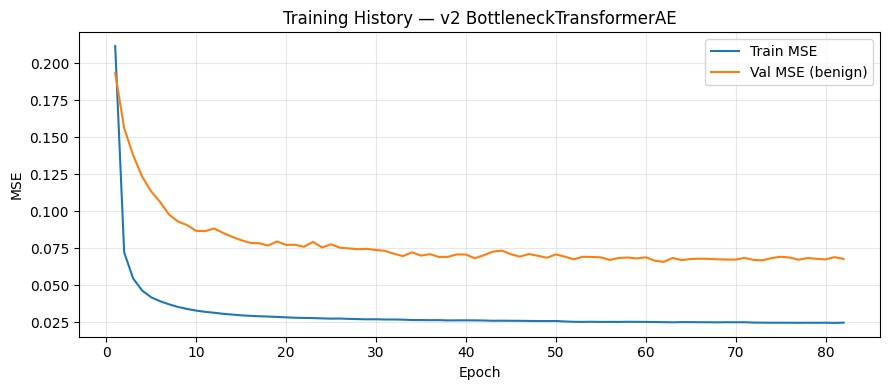

In [10]:
import matplotlib.pyplot as plt

epochs_h   = [r['epoch'] for r in history]
train_h    = [r['train_mse'] for r in history]
val_h      = [r['val_mse_benign'] for r in history]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs_h, train_h, label='Train MSE', linewidth=1.5)
ax.plot(epochs_h, val_h,   label='Val MSE (benign)', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Training History — v2 BottleneckTransformerAE')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RUN_DIR / 'training_history.png', dpi=150)
plt.show()

## 6. Anomaly Scoring

**v2 improvement:** Weighted combination of mean + max reconstruction error.
- Mean error captures sustained reconstruction failure (typical of attack patterns)
- Max error catches single-timestep bursts (e.g., brief DDoS spikes)

Score = `SCORE_MEAN_W × mean_error + SCORE_MAX_W × max_error`

In [11]:
@torch.no_grad()
def compute_scores(
    X: np.ndarray,
    batch_size: int = SCORE_BATCH_SIZE,
    mean_w: float = SCORE_MEAN_W,
    max_w: float  = SCORE_MAX_W,
) -> np.ndarray:
    """Weighted score processed in small batches to keep peak RAM low."""
    model.eval()
    scores = []
    for start in range(0, len(X), batch_size):
        xb    = torch.from_numpy(X[start:start + batch_size]).float().to(device)
        recon = model(xb)
        err   = (recon - xb) ** 2
        score = mean_w * err.mean(dim=(1, 2)) + max_w * err.amax(dim=(1, 2))
        scores.append(score.cpu().numpy())
        del xb, recon, err, score   # free each batch immediately
    return np.concatenate(scores)


s_val  = compute_scores(X_val)
s_test = compute_scores(X_test)

print(f"Val  scores : min={s_val.min():.6f}  max={s_val.max():.6f}  mean={s_val.mean():.6f}")
print(f"Test scores : min={s_test.min():.6f}  max={s_test.max():.6f}  mean={s_test.mean():.6f}")

from sklearn.metrics import roc_auc_score, average_precision_score
print(f"\nVal  ROC-AUC : {roc_auc_score(y_val,  s_val):.4f}")
print(f"Test ROC-AUC : {roc_auc_score(y_test, s_test):.4f}")


Val  scores : min=0.040793  max=7.659345  mean=0.749416
Test scores : min=0.037608  max=6.971487  mean=0.768041

Val  ROC-AUC : 0.5515
Test ROC-AUC : 0.5425


## 7. Multiple Thresholding Strategies

| Strategy | How selected | Best when |
|---|---|---|
| Youden J | max(TPR − FPR) on val ROC | Balanced TPR/FPR |
| p95 benign | 95th percentile of benign val scores | Low FPR priority |
| p99 benign | 99th percentile of benign val scores | Very low FPR |
| F1-optimal | max F1 over all val thresholds | Max attack recall+precision balance |
| Precision-target | lowest threshold where precision ≥ 0.85 | Minimize false alarms |

In [12]:
from sklearn.metrics import roc_curve, precision_recall_curve
import numpy as np

PRECISION_TARGET = 0.85


def compute_thresholds(s_val: np.ndarray, y_val: np.ndarray) -> dict:
    thresholds = {}

    # 1. Youden J
    fpr, tpr, thr_roc = roc_curve(y_val, s_val)
    j_scores = tpr[1:] - fpr[1:]
    ix = int(np.argmax(j_scores))
    thresholds['youden_j'] = float(thr_roc[ix])

    # 2. p95 benign
    s_benign = s_val[y_val == 0]
    thresholds['p95_benign'] = float(np.percentile(s_benign, 95))

    # 3. p99 benign
    thresholds['p99_benign'] = float(np.percentile(s_benign, 99))

    # 4. F1-optimal (scan all precision-recall curve thresholds)
    prec, rec, thr_pr = precision_recall_curve(y_val, s_val)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    ix_f1 = int(np.argmax(f1s))
    thresholds['f1_optimal'] = float(thr_pr[ix_f1])

    # 5. Precision-target: lowest threshold achieving ≥ PRECISION_TARGET
    valid = np.where(prec[:-1] >= PRECISION_TARGET)[0]
    if len(valid) > 0:
        thresholds['precision_target'] = float(thr_pr[valid[-1]])  # lowest threshold
    else:
        thresholds['precision_target'] = float(thresholds['p99_benign'])  # fallback

    return thresholds


thresholds = compute_thresholds(s_val, y_val)
print('Thresholds from validation:')
for name, val in thresholds.items():
    print(f'  {name:20s}: {val:.6f}')

Thresholds from validation:
  youden_j            : 0.173142
  p95_benign          : 4.621006
  p99_benign          : 4.802486
  f1_optimal          : 0.162070
  precision_target    : 4.802486


## 8. Complete Evaluation Framework

Reports all metrics for every threshold strategy on the **test set** (first time test is touched).

In [13]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, f1_score,
    matthews_corrcoef, balanced_accuracy_score,
)


def full_eval(
    s: np.ndarray,
    y: np.ndarray,
    threshold: float,
    label: str = '',
) -> dict:
    y_pred = (s >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()

    roc_auc   = roc_auc_score(y, s)
    pr_auc    = average_precision_score(y, s)
    f1        = f1_score(y, y_pred, zero_division=0)
    mcc       = matthews_corrcoef(y, y_pred)
    bal_acc   = balanced_accuracy_score(y, y_pred)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr       = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    result = dict(
        threshold=threshold, roc_auc=roc_auc, pr_auc=pr_auc,
        f1=f1, mcc=mcc, balanced_acc=bal_acc,
        precision=precision, recall=recall,
        specificity=specificity, fpr=fpr, fnr=fnr,
        tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn),
    )

    if label:
        print(f'\n=== {label} ===')
        print(f'  Threshold    : {threshold:.6f}')
        print(f'  ROC-AUC      : {roc_auc:.4f}')
        print(f'  PR-AUC       : {pr_auc:.4f}')
        print(f'  F1           : {f1:.4f}')
        print(f'  MCC          : {mcc:.4f}')
        print(f'  Balanced Acc : {bal_acc:.4f}')
        print(f'  Precision    : {precision:.4f}  Recall  : {recall:.4f}')
        print(f'  Specificity  : {specificity:.4f}  FPR     : {fpr:.4f}  FNR: {fnr:.4f}')
        print(f'  Confusion    : TP={tp} FP={fp} TN={tn} FN={fn}')

    return result


# Evaluate all threshold strategies on TEST
all_results = {}
for name, thr in thresholds.items():
    all_results[name] = full_eval(s_test, y_test, thr, label=name)

# Summary table
print('\n' + '='*80)
print(f'{"Strategy":<20} {"ROC-AUC":>8} {"PR-AUC":>8} {"F1":>7} {"MCC":>7} {"BalAcc":>8} {"FPR":>7} {"FNR":>7}')
print('-'*80)
for name, r in all_results.items():
    print(
        f'{name:<20} {r["roc_auc"]:>8.4f} {r["pr_auc"]:>8.4f}'
        f' {r["f1"]:>7.4f} {r["mcc"]:>7.4f} {r["balanced_acc"]:>8.4f}'
        f' {r["fpr"]:>7.4f} {r["fnr"]:>7.4f}'
    )
print('='*80)


=== youden_j ===
  Threshold    : 0.173142
  ROC-AUC      : 0.5425
  PR-AUC       : 0.6162
  F1           : 0.8092
  MCC          : 0.3305
  Balanced Acc : 0.6279
  Precision    : 0.7181  Recall  : 0.9267
  Specificity  : 0.3291  FPR     : 0.6709  FNR: 0.0733
  Confusion    : TP=6285 FP=2467 TN=1210 FN=497

=== p95_benign ===
  Threshold    : 4.621006
  ROC-AUC      : 0.5425
  PR-AUC       : 0.6162
  F1           : 0.0037
  MCC          : -0.1711
  Balanced Acc : 0.4754
  Precision    : 0.0647  Recall  : 0.0019
  Specificity  : 0.9489  FPR     : 0.0511  FNR: 0.9981
  Confusion    : TP=13 FP=188 TN=3489 FN=6769

=== p99_benign ===
  Threshold    : 4.802486
  ROC-AUC      : 0.5425
  PR-AUC       : 0.6162
  F1           : 0.0038
  MCC          : -0.0698
  Balanced Acc : 0.4944
  Precision    : 0.2131  Recall  : 0.0019
  Specificity  : 0.9869  FPR     : 0.0131  FNR: 0.9981
  Confusion    : TP=13 FP=48 TN=3629 FN=6769

=== f1_optimal ===
  Threshold    : 0.162070
  ROC-AUC      : 0.5425
  

## 9. Score Distribution & ROC/PR Curves

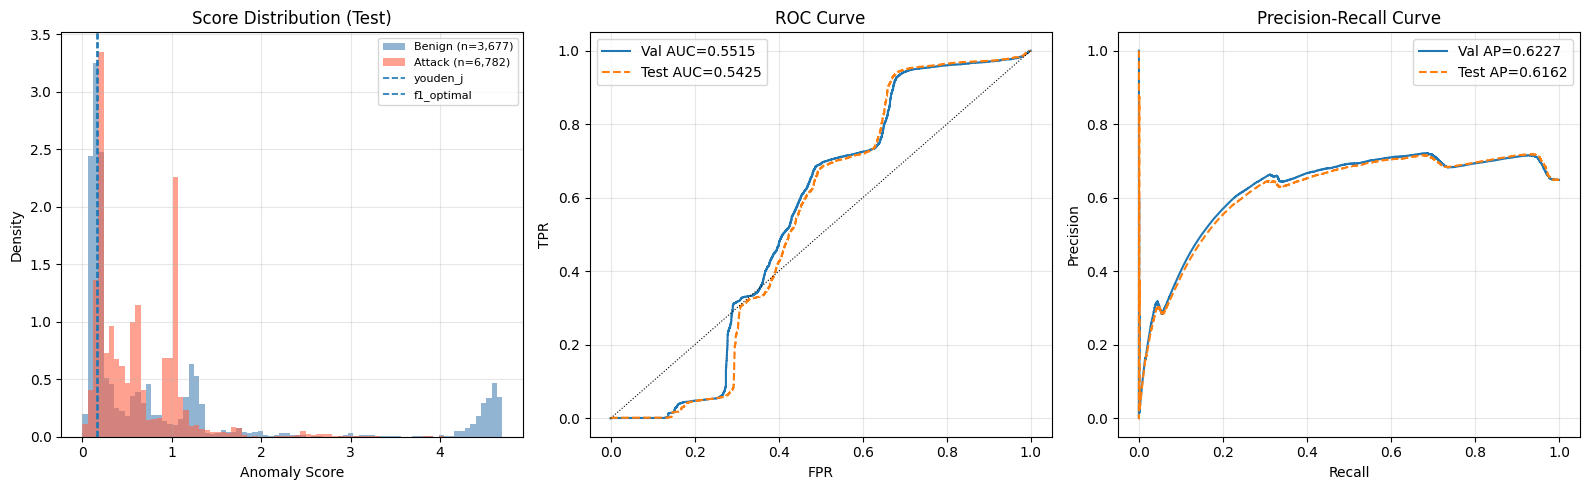

Plots saved.


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Score distribution
ax = axes[0]
s_ben = s_test[y_test == 0]
s_att = s_test[y_test == 1]
bins = np.linspace(0, np.percentile(s_test, 99), 80)
ax.hist(s_ben, bins=bins, alpha=0.6, label=f'Benign (n={len(s_ben):,})', color='steelblue', density=True)
ax.hist(s_att, bins=bins, alpha=0.6, label=f'Attack (n={len(s_att):,})', color='tomato',    density=True)
for tname, tval in thresholds.items():
    if tname in ('youden_j', 'f1_optimal'):
        ax.axvline(tval, linestyle='--', linewidth=1.2, label=tname)
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution (Test)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 2. ROC curve
ax = axes[1]
for split, s, y, style in [
    ('Val',  s_val,  y_val,  '-'),
    ('Test', s_test, y_test, '--'),
]:
    fpr_r, tpr_r, _ = roc_curve(y, s)
    auc = roc_auc_score(y, s)
    ax.plot(fpr_r, tpr_r, linestyle=style, label=f'{split} AUC={auc:.4f}')
ax.plot([0,1],[0,1],'k:',linewidth=0.8)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC Curve')
ax.legend()
ax.grid(alpha=0.3)

# 3. PR curve
ax = axes[2]
for split, s, y, style in [
    ('Val',  s_val,  y_val,  '-'),
    ('Test', s_test, y_test, '--'),
]:
    prec_r, rec_r, _ = precision_recall_curve(y, s)
    ap = average_precision_score(y, s)
    ax.plot(rec_r, prec_r, linestyle=style, label=f'{split} AP={ap:.4f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RUN_DIR / 'evaluation_plots.png', dpi=150)
plt.show()
print('Plots saved.')

## 10. Optuna HPO — Automated Hyperparameter Search

Optimizes **validation ROC-AUC** as the objective.

**Search space:**
- `d_model`: {32, 64, 128}
- `bottleneck_dim`: {16, 32, 64}
- `num_enc_layers`: {1, 2, 3}
- `num_dec_layers`: {1, 2, 3}
- `dim_ff`: {128, 256, 512}
- `dropout`: [0.05, 0.35]
- `lr`: log-uniform [1e-4, 1e-2]
- `noise_std`: [0.01, 0.15]

**Pruning:** MedianPruner — stops unpromising trials early based on intermediate val loss.

In [15]:
import optuna
from sklearn.metrics import roc_auc_score

optuna.logging.set_verbosity(optuna.logging.WARNING)


def hpo_objective(trial: optuna.Trial) -> float:
    d_model        = trial.suggest_categorical("d_model",        [32, 64, 128])
    bottleneck_dim = trial.suggest_categorical("bottleneck_dim", [16, 32, 64])
    num_enc_layers = trial.suggest_int("num_enc_layers", 1, 3)
    num_dec_layers = trial.suggest_int("num_dec_layers", 1, 2)
    dim_ff         = trial.suggest_categorical("dim_ff",         [64, 128, 256])
    dropout        = trial.suggest_float("dropout",   0.05, 0.35)
    lr             = trial.suggest_float("lr",        1e-4, 1e-2, log=True)
    noise_std      = trial.suggest_float("noise_std", 0.01, 0.15)

    if bottleneck_dim > d_model:
        raise optuna.exceptions.TrialPruned()

    nhead = 4 if d_model % 4 == 0 else 2
    m = build_model(
        n_features=n_features, d_model=d_model, nhead=nhead,
        num_enc_layers=num_enc_layers, num_dec_layers=num_dec_layers,
        dim_ff=dim_ff, dropout=dropout, bottleneck_dim=bottleneck_dim,
    )
    loader = DataLoader(
        TensorDataset(X_train_t), batch_size=BATCH_SIZE,
        shuffle=True, drop_last=False, pin_memory=False, num_workers=0,
    )
    optimizer_m = optim.AdamW(m.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    xv_b = X_val_t[y_val == 0].to(device)
    best_val, no_imp = float("inf"), 0

    for epoch in range(1, HPO_MAX_EPOCH + 1):
        m.train()
        for (xb,) in loader:
            xb = xb.to(device)
            xb_in = add_noise(xb, noise_std)
            optimizer_m.zero_grad(set_to_none=True)
            loss = F.mse_loss(m(xb_in), xb)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), GRAD_CLIP)
            optimizer_m.step()
        m.eval()
        with torch.no_grad():
            val_mse = float(F.mse_loss(m(xv_b), xv_b).item())
        trial.report(val_mse, epoch)
        if trial.should_prune():
            del m, optimizer_m, xv_b, loader
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
            raise optuna.exceptions.TrialPruned()
        if val_mse < best_val - 1e-6:
            best_val, no_imp = val_mse, 0
        else:
            no_imp += 1
        if no_imp >= HPO_PATIENCE:
            break

    m.eval()
    s_chunks = []
    with torch.no_grad():
        for start in range(0, len(X_val), SCORE_BATCH_SIZE):
            xb    = torch.from_numpy(X_val[start:start+SCORE_BATCH_SIZE]).float().to(device)
            recon = m(xb)
            err   = (recon - xb) ** 2
            score = SCORE_MEAN_W * err.mean(dim=(1,2)) + SCORE_MAX_W * err.amax(dim=(1,2))
            s_chunks.append(score.cpu().numpy())
            del xb, recon, err, score
    s_v = np.concatenate(s_chunks)

    del m, optimizer_m, xv_b, loader, s_chunks
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    try:
        return float(roc_auc_score(y_val, s_v))
    except Exception:
        return 0.5


study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
    study_name="mdc_v2_hpo",
)
print(f"Starting Optuna HPO: {N_TRIALS} trials, up to {HPO_MAX_EPOCH} epochs each ...")
study.optimize(hpo_objective, n_trials=N_TRIALS, show_progress_bar=True)

best = study.best_trial
print(f"\nBest  Val ROC-AUC: {best.value:.4f}  Params: {best.params}")
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()


Starting Optuna HPO: 15 trials, up to 30 epochs each ...


  0%|          | 0/15 [00:00<?, ?it/s]

/tmp/ipykernel_4436/219564743.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
/tmp/ipykernel_4436/219564743.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
/tmp/ipykernel_4436/219564743.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
/tmp/ipykernel_4436/219564743.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
/tmp/ipykernel_4436/219564743.py:61: UserWarning: enable_nes


Best  Val ROC-AUC: 0.6633  Params: {'d_model': 128, 'bottleneck_dim': 32, 'num_enc_layers': 3, 'num_dec_layers': 2, 'dim_ff': 64, 'dropout': 0.10878859966131471, 'lr': 0.0009297788639728521, 'noise_std': 0.10518039001174652}


In [16]:
print("Retraining with best HPO params ...")
bp         = best.params
nhead_best = 4 if bp["d_model"] % 4 == 0 else 2

model_best = build_model(
    n_features=n_features,
    d_model=bp["d_model"],        nhead=nhead_best,
    num_enc_layers=bp["num_enc_layers"],
    num_dec_layers=bp["num_dec_layers"],
    dim_ff=bp["dim_ff"],          dropout=bp["dropout"],
    bottleneck_dim=bp["bottleneck_dim"],
)
loader_best = DataLoader(
    TensorDataset(X_train_t), batch_size=BATCH_SIZE,
    shuffle=True, drop_last=False, pin_memory=False, num_workers=0,
)
_, history_best = train_model(
    model_best, loader_best, X_val_t, y_val,
    lr=bp["lr"], noise_std=bp["noise_std"], use_denoising=True, verbose=True,
)
del loader_best
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

model       = model_best
s_val_best  = compute_scores(X_val)
s_test_best = compute_scores(X_test)
thresholds_best = compute_thresholds(s_val_best, y_val)

print("\n=== HPO Best Model  Test Evaluation ===")
print(f"{"Strategy":<20} {"ROC-AUC":>8} {"PR-AUC":>8} {"F1":>7} {"MCC":>7} {"BalAcc":>8} {"FPR":>7} {"FNR":>7}")
print("-"*80)
for name, thr in thresholds_best.items():
    r = full_eval(s_test_best, y_test, thr)
    print(f"{name:<20} {r['roc_auc']:>8.4f} {r['pr_auc']:>8.4f}"
          f" {r['f1']:>7.4f} {r['mcc']:>7.4f} {r['balanced_acc']:>8.4f}"
          f" {r['fpr']:>7.4f} {r['fnr']:>7.4f}")
print("="*80)


Retraining with best HPO params ...


/tmp/ipykernel_4436/219564743.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


epoch 001  train=0.091594  val_benign=0.104156  lr=9.30e-04 *
epoch 002  train=0.027724  val_benign=0.071365  lr=9.30e-04 *
epoch 003  train=0.020642  val_benign=0.057838  lr=9.30e-04 *
epoch 004  train=0.017474  val_benign=0.050404  lr=9.30e-04 *
epoch 005  train=0.015394  val_benign=0.043751  lr=9.30e-04 *
epoch 006  train=0.014020  val_benign=0.040890  lr=9.30e-04 *
epoch 008  train=0.012478  val_benign=0.040026  lr=9.30e-04 *
epoch 009  train=0.011888  val_benign=0.038639  lr=9.30e-04 *
epoch 010  train=0.011349  val_benign=0.035037  lr=9.30e-04 *
epoch 011  train=0.011000  val_benign=0.034744  lr=9.30e-04 *
epoch 012  train=0.010699  val_benign=0.033724  lr=9.30e-04 *
epoch 019  train=0.009497  val_benign=0.033634  lr=9.30e-04 *
epoch 020  train=0.009351  val_benign=0.034934  lr=9.30e-04
epoch 022  train=0.009124  val_benign=0.031554  lr=9.30e-04 *
epoch 030  train=0.008707  val_benign=0.032794  lr=9.30e-04
epoch 033  train=0.008008  val_benign=0.031410  lr=4.65e-04 *
epoch 035  t

## 11. Save Final Model & Results

In [18]:
from datetime import datetime, timezone

# Save HPO best checkpoint
torch.save({
    'model': model_best.state_dict(),
    'hpo_params': bp,
    'val_roc_auc': best.value,
    'config': {
        'T': T, 'n_features': n_features,
        'd_model': bp['d_model'], 'bottleneck_dim': bp['bottleneck_dim'],
        'nhead': nhead_best, 'num_enc_layers': bp['num_enc_layers'],
        'num_dec_layers': bp['num_dec_layers'], 'dim_ff': bp['dim_ff'],
        'dropout': bp['dropout'],
    },
}, RUN_DIR / 'checkpoint_v2_best.pt')

# Save scores
np.savez_compressed(
    RUN_DIR / 'scores_v2.npz',
    s_val=s_val_best, s_test=s_test_best,
    y_val=y_val, y_test=y_test,
)

# Build final metrics dict using best threshold (youden_j)
thr_final = thresholds_best['youden_j']
final     = full_eval(s_test_best, y_test, thr_final)

summary = {
    'created_at'     : datetime.now(timezone.utc).isoformat(),
    'version'        : 'v2',
    'hpo_params'     : bp,
    'thresholds'     : thresholds_best,
    'default_threshold': thr_final,
    'test_roc_auc'   : final['roc_auc'],
    'test_pr_auc'    : final['pr_auc'],
    'test_f1'        : final['f1'],
    'test_mcc'       : final['mcc'],
    'test_balanced_acc': final['balanced_acc'],
    'test_precision' : final['precision'],
    'test_recall'    : final['recall'],
    'test_specificity': final['specificity'],
    'test_fpr'       : final['fpr'],
    'test_fnr'       : final['fnr'],
    'confusion'      : {'tp': final['tp'], 'fp': final['fp'], 'tn': final['tn'], 'fn': final['fn']},
    'train_shapes'   : {'X_train': list(X_train_t.shape), 'X_val': list(X_val.shape), 'X_test': list(X_test.shape)},
}

(RUN_DIR / 'metrics_v2.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('All artifacts saved to:', RUN_DIR)
print(json.dumps({
    'test_roc_auc'  : round(final['roc_auc'], 4),
    'test_pr_auc'   : round(final['pr_auc'],  4),
    'test_f1'       : round(final['f1'],       4),
    'test_mcc'      : round(final['mcc'],      4),
    'test_balanced_acc': round(final['balanced_acc'], 4),
    'test_fpr'      : round(final['fpr'],      4),
    'test_fnr'      : round(final['fnr'],      4),
}, indent=2))

All artifacts saved to: /content/drive/MyDrive/Module4_MDC/runs/v2_run
{
  "test_roc_auc": 0.6407,
  "test_pr_auc": 0.6739,
  "test_f1": 0.8388,
  "test_mcc": 0.4766,
  "test_balanced_acc": 0.7108,
  "test_fpr": 0.4942,
  "test_fnr": 0.0842
}


## 12. Fallback: Run Without HPO (Default Config)

If Optuna is unavailable or HPO is too slow, use the default-config model trained in §5.
This cell re-evaluates that model so results are always available regardless of HPO.

In [19]:
ckpt = torch.load(RUN_DIR / "checkpoint_v2.pt", map_location=device)
m_default = build_model(
    n_features=ckpt["config"]["n_features"],
    d_model=ckpt["config"]["d_model"],
    bottleneck_dim=ckpt["config"]["bottleneck_dim"],
    num_enc_layers=ckpt["config"]["num_enc_layers"],
    num_dec_layers=ckpt["config"]["num_dec_layers"],
    dim_ff=ckpt["config"]["dim_ff"],
    dropout=ckpt["config"]["dropout"],
)
m_default.load_state_dict(ckpt["model"])
m_default.eval()
del ckpt
gc.collect()

_model_backup = model
model = m_default
s_val_def  = compute_scores(X_val)
s_test_def = compute_scores(X_test)
thr_def    = compute_thresholds(s_val_def, y_val)
model = _model_backup
del m_default, _model_backup
gc.collect()

print("=== Default Config Model (no HPO) — Test Results ===")
r_def = full_eval(s_test_def, y_test, thr_def["youden_j"], label="default/youden_j")
print(f"  ROC-AUC: {r_def['roc_auc']:.4f}  PR-AUC: {r_def['pr_auc']:.4f}  F1: {r_def['f1']:.4f}")


/tmp/ipykernel_4436/219564743.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


=== Default Config Model (no HPO) — Test Results ===

=== default/youden_j ===
  Threshold    : 0.173142
  ROC-AUC      : 0.5425
  PR-AUC       : 0.6162
  F1           : 0.8092
  MCC          : 0.3305
  Balanced Acc : 0.6279
  Precision    : 0.7181  Recall  : 0.9267
  Specificity  : 0.3291  FPR     : 0.6709  FNR: 0.0733
  Confusion    : TP=6285 FP=2467 TN=1210 FN=497
  ROC-AUC: 0.5425  PR-AUC: 0.6162  F1: 0.8092
